In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

# Load Dataset

In [15]:
file_path = "../datasets/phase_1/paysim-dataset.parquet"
df_clean = pd.read_parquet(file_path)
df_clean.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,-0.332937,1.452975,-0.140722,0,-0.969372,0.00000,1,0,False,False,False,True,False
1,1,-0.373767,0.065605,-0.140722,0,-0.183663,0.00000,1,0,False,False,False,True,False
2,1,-0.382384,-0.130713,-0.140722,1,-0.017832,0.00000,0,1,False,False,False,False,True
3,1,-0.382384,-0.130713,-0.118260,1,-0.017832,-0.14206,0,1,False,True,False,False,False
4,1,-0.323576,0.254812,-0.140722,0,-1.149510,0.00000,1,0,False,False,False,True,False


# Sampling

In [ ]:
# Using Slovin Algorithm for minimal sample
# n = N / (1 + N * e^2)
# n = 6362604 / (1 + 6362604 * (0.01)^2)
# n = 9.984,307
# or rounded to 10.000

# from sklearn.model_selection import train_test_split
# df_sample, _ = train_test_split(df_clean, train_size=10000, stratify=df_clean['isDestMerchant'], random_state=42)

In [ ]:
X_clean = df_clean.drop(columns=['isFraud'], errors='ignore')
# X_sample = df_sample.drop(columns=['isFraud'], errors='ignore')

# Elbow Method

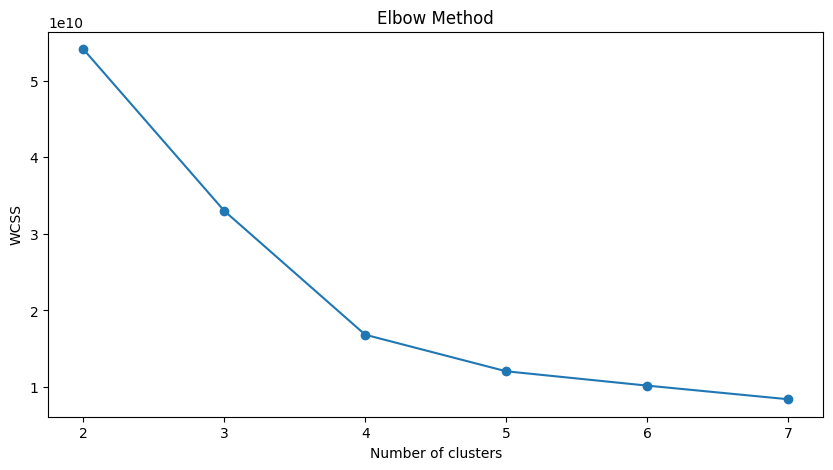

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clean)
    wcss.append(kmeans.inertia_)
    # score = silhouette_score(X_clean, labels)
    # print(f"K={i}, Silhouette Score={score}")

plt.figure(figsize=(10, 5))
plt.plot(range(2, 8), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# KMeans Clustering

In [19]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_clean)
# df_sample['cluster_kmeans'] = df_clean.loc[df_sample.index, 'cluster_kmeans']

# Dimensional Reduction

In [20]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_clean).astype('float32')

# HDBSCAN Outlier Detection

In [ ]:
import hdbscan

# take random to train HDBSCAN
np.random.seed(42)
sample_indices = np.random.choice(X_reduced.shape[0], size=100000, replace=False)
X_reduced_sample = X_reduced[sample_indices]

hdbscan_cpu = hdbscan.HDBSCAN(
    min_cluster_size=1000,
    min_samples=50,
    prediction_data=True,
    core_dist_n_jobs=-1
)
hdbscan_cpu.fit(X_reduced_sample)

# Batching
batch_size = 500000
all_labels = []

for i in range(0, len(X_reduced), batch_size):
    X_batch = X_reduced[i : i+ batch_size]
    batch_labels, _ = hdbscan.approximate_predict(hdbscan_cpu, X_batch)
    all_labels.extend(batch_labels)

df_clean['cluster_hdbscan'] = all_labels

outlier_count = (df_clean['cluster_hdbscan'] == -1).sum()
print(f'Outier count from hDBCSAN (label -1): {outlier_count} dots')

# RAM cleaning
del X_reduced, X_reduced_sample, hdbscan_cpu, all_labels, X_batch, batch_labels
gc.collect()

Outier count from hDBCSAN (label -1): 54295 dots


22963

# Hierarchical Cluster

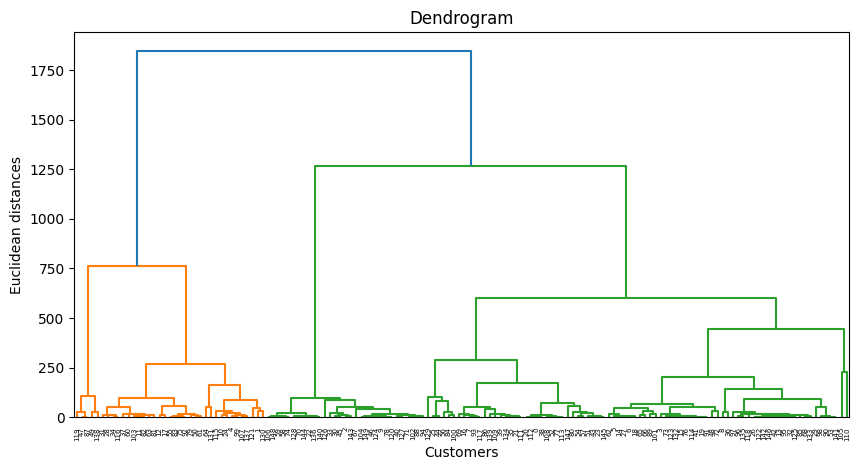

In [ ]:
import scipy.cluster.hierarchy as sch 

df_dendro = df_sample.sample(150, random_state=42)
plt.figure(figsize=(10, 5))
plt.title('Dendrogram')
dendrogram = sch.dendrogram(sch.linkage(df_dendro.drop(columns=['cluster_kmeans', 'cluster_hdbscan', 'isFraud'], errors='ignore'), method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

# Profiling Cluster

In [23]:
cluster_profiles = df_clean.groupby('cluster_kmeans').mean()
print("Cluster Profile (Mean):")
print(cluster_profiles)

Cluster Profile (Mean):
                      step    amount  oldbalanceOrg  oldbalanceDest   isFraud  \
cluster_kmeans                                                                  
0               194.207430  0.410346       7.547514        0.918856  0.000664   
1               342.195684  0.725318       7.811205        1.187423  0.000896   
2                27.685679  0.427678       7.991877        0.894793  0.001246   
3               582.389730  0.503072       5.997228        1.103245  0.008835   

                balanceDiffOrig  balanceDiffDest  isDestMerchant  \
cluster_kmeans                                                     
0                      2.187311         0.600594        0.336006   
1                      2.197891         1.077597        0.338166   
2                      1.930995         0.907605        0.339668   
3                      1.126779         0.623810        0.349263   

                origDrainedToZero  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
cl

# Cluster Visualization

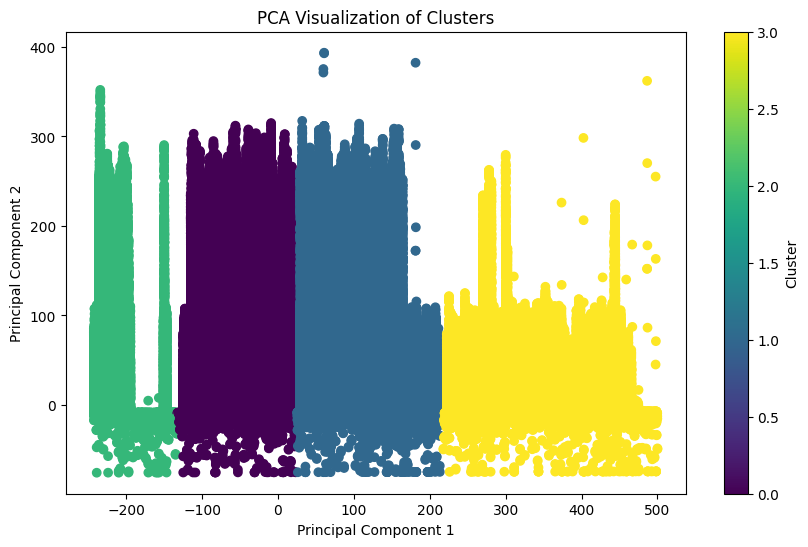

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_sample.drop(columns=['cluster_hdbscan'], errors='ignore'))

plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df_clean['cluster_kmeans'] if 'cluster_kmeans' in df_clean else None, cmap='viridis')
plt.title('PCA Visualization of Clusters')
plt.colorbar(label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Export

In [26]:
folder_path = "../datasets/phase_2"

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

df_clean.to_parquet(os.path.join(folder_path, 'paysim-dataset-phase2.parquet'), index=False)

# Outliers for phase 4
df_outliers = df_clean[df_clean['cluster_hdbscan'] == -1].copy()
df_outliers.to_parquet(os.path.join(folder_path, 'paysim-outliers-phase4.parquet'), index=False)

# Profile cluster
cluster_profiles.to_csv(os.path.join(folder_path, 'cluster-summary-phase2.csv'))

del df_outliers, cluster_profiles
gc.collect()

25956